<div style="  background: linear-gradient(145deg, #0f172a, #1e293b);  border: 4px solid transparent;  border-radius: 14px;  padding: 18px 22px;  margin: 12px 0;  font-size: 26px;  font-weight: 600;  color: #f8fafc;  box-shadow: 0 6px 14px rgba(0,0,0,0.25);  background-clip: padding-box;  position: relative;">  <div style="    position: absolute;    inset: 0;    padding: 4px;    border-radius: 14px;    background: linear-gradient(90deg, #06b6d4, #3b82f6, #8b5cf6);    -webkit-mask:       linear-gradient(#fff 0 0) content-box,       linear-gradient(#fff 0 0);    -webkit-mask-composite: xor;    mask-composite: exclude;    pointer-events: none;  "></div>    <b>Topic Modeling with LDA & NMF</b>    <br/>  <span style="color:#9ca3af; font-size: 18px; font-weight: 400;">(Unsupervised Topic Discovery with Gensim & Scikit-Learn)</span></div>

## Table of Contents
1. [Introduction to Topic Modeling & Motivation](#section-1)
2. [Environment Setup & NLP Toolkit](#section-2)
3. [Text Preprocessing & Phrasing for Topic Models](#section-3)
4. [Building Gensim Dictionary & Pruning Extremes](#section-4)
5. [TF-IDF Transformation with Gensim](#section-5)
6. [Latent Dirichlet Allocation (LDA): Mathematical Theory](#section-6)
7. [Training and Interpreting LDA Models with Gensim](#section-7)
8. [Document-Topic Distributions & Inferences for Unseen Text](#section-8)
9. [Topic Model Evaluation: Perplexity & Topic Coherence ($C_v$)](#section-9)
10. [Alternative Topic Modeling: NMF & Scikit-Learn Implementation](#section-10)
11. [Project: Discovering Latent Themes in Movie Overviews](#section-11)
12. [Topic Visualizations with Matplotlib & Best Practices](#section-12)
13. [Review and Conclusion](#section-13)

---

<br><span style="  display: inline-block;  color: #fff;  background: linear-gradient(135deg, #a31616ff, #02b7ffff);  padding: 12px 20px;  border-radius: 12px;  font-size: 28px;  font-weight: 700;  box-shadow: 0 4px 12px rgba(0,0,0,0.2);  transition: transform 0.2s ease, box-shadow 0.2s ease;">  🧾 1. Introduction to Topic Modeling & Motivation</span><br>

### What is Topic Modeling?
In modern text analytics, organizations collect massive archives of unstructured text—news articles, customer reviews, medical journals, legal briefs, and social media posts. Unlike supervised text classification (where every document has an explicit label such as `spam` or `ham`), the vast majority of real-world text arrives **unlabeled**.

**Topic Modeling** is an unsupervised Machine Learning technique that automatically scans a collection of documents, detects repeating word clusters, and extracts abstract semantic themes ("topics").

| Dimension | Supervised Classification | Unsupervised Clustering | Topic Modeling (LDA / NMF) |
| :--- | :--- | :--- | :--- |
| **Labels Required** | Yes (Ground truth classes) | No (Unlabeled) | No (Unlabeled) |
| **Output** | Single discrete class per document | Hard cluster assignment (1 cluster/doc) | Soft mixture of topics per document |
| **Document Assumption** | One label per document | One cluster per document | Documents contain multiple topics |
| **Core Algorithms** | Logistic Regression, Naive Bayes, SVM | K-Means, DBSCAN, Hierarchical | LDA, NMF, LSA, BERTopic |

### Why Documents Are Multi-Topic Mixtures
A single document rarely discusses only one subject. For example, a news article about *the economic impact of climate change on agriculture* contains vocabulary from:
1. **Climate Science**: *carbon, emissions, warming, drought*
2. **Economics & Policy**: *inflation, investment, subsidies, trade*
3. **Agriculture**: *crops, harvest, irrigation, farmers*

Topic modeling models this reality mathematically: every document is treated as a **probability distribution over topics**, and every topic is a **probability distribution over words**.

<div style="background: #e0f2fe; border-left: 16px solid #0284c7; padding: 14px 18px; border-radius: 8px; font-size: 18px; color: #075985;"> 💡 <b>Tip:</b> In Notebook 02, we introduced Gensim dictionaries and Bag-of-Words corpora, noting that they lay the foundation for Topic Modeling. In this notebook, we unlock the full power of Gensim and Scikit-Learn to discover latent topics. </div>

---

<br><span style="  display: inline-block;  color: #fff;  background: linear-gradient(135deg, #a31616ff, #02b7ffff);  padding: 12px 20px;  border-radius: 12px;  font-size: 28px;  font-weight: 700;  box-shadow: 0 4px 12px rgba(0,0,0,0.2);  transition: transform 0.2s ease, box-shadow 0.2s ease;">  🧾 2. Environment Setup & NLP Toolkit</span><br>

We utilize Python's premier NLP and Machine Learning libraries:
* **Gensim**: The gold standard library for unsupervised topic modeling, word embeddings, and document indexing.
* **NLTK**: For specialized text preprocessing, token extraction, and lemmatization.
* **Scikit-Learn**: For matrix factorization (NMF) and linear algebraic text transformations.
* **Pandas & Matplotlib**: For tabular manipulation and publication-quality topic visualizations.


In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# NLTK dependencies
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

# Gensim for Topic Modeling
import gensim
from gensim.corpora import Dictionary
from gensim.models import LdaModel, CoherenceModel, Phrases, TfidfModel
from gensim.models.phrases import Phraser

# Scikit-Learn for matrix decomposition and vectorization
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation, NMF

print(f"Gensim version: {gensim.__version__}")
print(f"NLTK version: {nltk.__version__}")
print("Setup complete! All topic modeling modules imported successfully.")


Gensim version: 4.4.0
NLTK version: 3.9.2
Setup complete! All topic modeling modules imported successfully.


---

<br><span style="  display: inline-block;  color: #fff;  background: linear-gradient(135deg, #a31616ff, #02b7ffff);  padding: 12px 20px;  border-radius: 12px;  font-size: 28px;  font-weight: 700;  box-shadow: 0 4px 12px rgba(0,0,0,0.2);  transition: transform 0.2s ease, box-shadow 0.2s ease;">  🧾 3. Text Preprocessing & Phrasing for Topic Models</span><br>

### Why Topic Modeling Requires Dedicated Preprocessing
Topic modeling is sensitive to vocabulary quality:
1. **Frequent Non-informative Words**: Words like *"the"*, *"and"*, *"said"*, *"one"* dominate frequency counts and can hijack topics.
2. **Infrequent Noise**: Words appearing only once across thousands of documents add computational overhead without offering topic clues.
3. **Compound Term Loss**: In standard unigram tokenization, *"artificial intelligence"* becomes separate tokens *"artificial"* and *"intelligence"*. In isolation, *"artificial"* could mean artificial turf, artificial sweetener, or artificial flowers!

### Detecting Multi-Word Expressions with Gensim Phrases
Gensim includes an automated collocation detector (`Phrases`) that calculates point-wise mutual information between adjacent words:

$$ \text{score}(w_a, w_b) = \frac{\text{count}(w_a, w_b) - \delta}{\text{count}(w_a) \times \text{count}(w_b)} \times N $$

If two words appear together much more frequently than expected by chance, Gensim glues them into a compound token: `artificial_intelligence`, `machine_learning`, `clinical_trials`.


In [2]:
# Sample multi-domain corpus: Technology, Sports, and Medicine
sample_articles = [
    "Artificial intelligence and deep learning models are transforming computer vision and robotics.",
    "Machine learning algorithms analyze large datasets to detect complex patterns and neural networks.",
    "The football team secured a thrilling victory in the national championship tournament.",
    "Athletes maintain rigorous fitness routines and cardiovascular training for peak performance.",
    "Clinical trials demonstrated that new immunotherapy treatments improve patient recovery times.",
    "Hospitals and medical researchers are testing novel vaccines to prevent chronic health conditions.",
    "Data science and artificial intelligence empower healthcare professionals with predictive diagnostics.",
    "Basketball players competed with intense agility during the playoff finals championship game."
]

# Initialize stop words and lemmatizer
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_and_tokenize(text):
    # Keep alphabetical tokens of length >= 3
    tokens = re.findall(r'[a-zA-Z]{3,}', text.lower())
    # Remove stopwords and reduce to root lemma
    lemmas = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words]
    return lemmas

# Apply unigram tokenization
tokenized_docs = [clean_and_tokenize(doc) for doc in sample_articles]

# Build Gensim Phrases model for bigrams
phrase_model = Phrases(tokenized_docs, min_count=1, threshold=1)
bigram_phraser = Phraser(phrase_model)

# Transform documents by fusing bigrams
docs_with_phrases = [bigram_phraser[doc] for doc in tokenized_docs]

print("Original Text Sample:")
print("  " + sample_articles[0])
print("\nCleaned & Bigram Phrased Tokens:")
print(f"  {docs_with_phrases[0]}")


Original Text Sample:
  Artificial intelligence and deep learning models are transforming computer vision and robotics.

Cleaned & Bigram Phrased Tokens:
  ['artificial_intelligence', 'deep', 'learning', 'model', 'transforming', 'computer', 'vision', 'robotics']


---

<br><span style="  display: inline-block;  color: #fff;  background: linear-gradient(135deg, #a31616ff, #02b7ffff);  padding: 12px 20px;  border-radius: 12px;  font-size: 28px;  font-weight: 700;  box-shadow: 0 4px 12px rgba(0,0,0,0.2);  transition: transform 0.2s ease, box-shadow 0.2s ease;">  🧾 4. Building Gensim Dictionary & Pruning Extremes</span><br>

### The Gensim Dictionary Object
The `gensim.corpora.Dictionary` maps every unique token in your preprocessed corpus to a unique integer ID.

### Pruning Extremes: `filter_extremes()`
One of Gensim's most powerful capabilities is `filter_extremes()`:
* **`no_below=k`**: Discard words that appear in fewer than $k$ documents. Removes typos, rare names, and noise.
* **`no_above=frac`**: Discard words that appear in more than `frac` (e.g. 80%) of documents. Removes corpus-specific stopwords that survived generic stopword filtering.
* **`keep_n=N`**: Keep only the top $N$ most frequent surviving words.

<div style="background: #e0f2fe; border-left: 16px solid #0284c7; padding: 14px 18px; border-radius: 8px; font-size: 18px; color: #075985;"> 💡 <b>Tip:</b> Pruning extremes prevents generic high-frequency words from drowning out subtle topic signals, resulting in much cleaner, more distinguishable topics. </div>

### Constructing the Bag-of-Words (BoW) Corpus
With the dictionary created, `doc2bow()` converts every document into a sparse vector representation:
`[(token_id_1, count_1), (token_id_2, count_2), ...]`


In [3]:
# 1. Create Gensim Dictionary
dictionary = Dictionary(docs_with_phrases)
print(f"Total Unique Tokens in Dictionary: {len(dictionary)}")

# 2. Filter Extremes (demonstrated with generous thresholds for small corpus)
dictionary.filter_extremes(no_below=1, no_above=0.90)
print(f"Tokens after filter_extremes: {len(dictionary)}")

# 3. Convert documents to BoW format
bow_corpus = [dictionary.doc2bow(doc) for doc in docs_with_phrases]

# Inspect sample BoW document
print("\nBoW representation of Document 1 (Sparse tuples of (ID, Frequency)):")
for token_id, freq in bow_corpus[0]:
    print(f"  Word: '{dictionary[token_id]:<22}' | ID: {token_id:<2} | Count: {freq}")


Total Unique Tokens in Dictionary: 70
Tokens after filter_extremes: 70

BoW representation of Document 1 (Sparse tuples of (ID, Frequency)):
  Word: 'artificial_intelligence' | ID: 0  | Count: 1
  Word: 'computer              ' | ID: 1  | Count: 1
  Word: 'deep                  ' | ID: 2  | Count: 1
  Word: 'learning              ' | ID: 3  | Count: 1
  Word: 'model                 ' | ID: 4  | Count: 1
  Word: 'robotics              ' | ID: 5  | Count: 1
  Word: 'transforming          ' | ID: 6  | Count: 1
  Word: 'vision                ' | ID: 7  | Count: 1


---

<br><span style="  display: inline-block;  color: #fff;  background: linear-gradient(135deg, #a31616ff, #02b7ffff);  padding: 12px 20px;  border-radius: 12px;  font-size: 28px;  font-weight: 700;  box-shadow: 0 4px 12px rgba(0,0,0,0.2);  transition: transform 0.2s ease, box-shadow 0.2s ease;">  🧾 5. TF-IDF Transformation with Gensim</span><br>

As mastered in Notebook 20, Term Frequency-Inverse Document Frequency (TF-IDF) adjusts raw word counts based on how uniquely informative a word is across the corpus.

In Gensim, transforming a raw BoW corpus into a TF-IDF corpus is handled by `gensim.models.TfidfModel`:
1. It trains on the `bow_corpus` to compute global Inverse Document Frequencies.
2. It projects any document bag-of-words into its TF-IDF vector.


In [4]:
# Fit TF-IDF model on BoW corpus
tfidf_model = TfidfModel(bow_corpus)

# Transform the BoW corpus into TF-IDF weighted sparse vectors
tfidf_corpus = tfidf_model[bow_corpus]

print("Comparing BoW Count vs. TF-IDF Weight for Document 1:")
for (token_id, count), (_, tfidf_val) in zip(bow_corpus[0][:5], tfidf_corpus[0][:5]):
    word = dictionary[token_id]
    print(f"  Token: {word:<22} -> BoW Count: {count} | TF-IDF Weight: {tfidf_val:.4f}")


Comparing BoW Count vs. TF-IDF Weight for Document 1:
  Token: artificial_intelligence -> BoW Count: 1 | TF-IDF Weight: 0.2540
  Token: computer               -> BoW Count: 1 | TF-IDF Weight: 0.3810
  Token: deep                   -> BoW Count: 1 | TF-IDF Weight: 0.3810
  Token: learning               -> BoW Count: 1 | TF-IDF Weight: 0.2540
  Token: model                  -> BoW Count: 1 | TF-IDF Weight: 0.3810


---

<br><span style="  display: inline-block;  color: #fff;  background: linear-gradient(135deg, #a31616ff, #02b7ffff);  padding: 12px 20px;  border-radius: 12px;  font-size: 28px;  font-weight: 700;  box-shadow: 0 4px 12px rgba(0,0,0,0.2);  transition: transform 0.2s ease, box-shadow 0.2s ease;">  🧾 6. Latent Dirichlet Allocation (LDA): Mathematical Theory</span><br>

### The Generative Story of LDA
Developed by David Blei, Andrew Ng, and Michael Jordan (2003), **Latent Dirichlet Allocation (LDA)** is a generative probabilistic model for text collections.

LDA assumes an imagined generative process for how every document in a collection was written:
1. For each document $d$:
   - Choose a topic proportion vector $\theta_d \sim \text{Dirichlet}(\alpha)$
2. For each word position $n$ in document $d$:
   - Choose a topic $z_{d,n} \sim \text{Multinomial}(\theta_d)$
   - Choose a word $w_{d,n} \sim \text{Multinomial}(\beta_{z_{d,n}})$

```
   [ Hyperparameter α ]             [ Hyperparameter η / β ]
           │                                   │
           ▼                                   ▼
    Topic Proportions θ_d               Word Distribution β_k
           │                                   │
           ▼                                   ▼
      Topic Assignment z_{d,n} ──────────► Word w_{d,n} (Observed)
```

### The Role of Dirichlet Priors: $\alpha$ and $\eta$ (or $\beta$)
A Dirichlet distribution is a probability distribution over probability distributions (a simplex).
* **$\alpha$ (Document-Topic Prior)**:
  - **High $\alpha$**: Documents are assumed to be a mixture of *many* topics (smoother, more balanced).
  - **Low $\alpha$**: Documents are assumed to concentrate on *only one or two* specific topics.
* **$\eta$ / $\beta$ (Topic-Word Prior)**:
  - **High $\eta$**: Topics are composed of *most words* in the vocabulary.
  - **Low $\eta$**: Topics are composed of *a few distinct, specialized words*.

### Mathematical Formulation
The joint distribution of topic mixture $\theta$, topics $\mathbf{z}$, and words $\mathbf{w}$ is given by:

$$ P(\mathbf{w}, \mathbf{z}, \theta, \Phi \mid \alpha, \beta) = \prod_{k=1}^K P(\phi_k \mid \beta) \prod_{d=1}^D P(\theta_d \mid \alpha) \left( \prod_{n=1}^{N_d} P(z_{d,n} \mid \theta_d) P(w_{d,n} \mid \phi_{z_{d,n}}) \right) $$

Because calculating the true posterior distribution is intractable, algorithms like **Collapsed Gibbs Sampling** and **Online Variational Bayes** (used by Gensim) approximate the posterior.


---

<br><span style="  display: inline-block;  color: #fff;  background: linear-gradient(135deg, #a31616ff, #02b7ffff);  padding: 12px 20px;  border-radius: 12px;  font-size: 28px;  font-weight: 700;  box-shadow: 0 4px 12px rgba(0,0,0,0.2);  transition: transform 0.2s ease, box-shadow 0.2s ease;">  🧾 7. Training and Interpreting LDA Models with Gensim</span><br>

### Key `LdaModel` Parameters:
* **`corpus`**: Stream of document vectors (`bow_corpus`).
* **`id2word`**: The mapping dictionary.
* **`num_topics`**: The number of latent topics $K$ to discover.
* **`passes`**: Number of passes through the entire corpus during training.
* **`alpha`**: Hyperparameter prior (`'auto'`, `'symmetric'`, or explicit float).
* **`eta`**: Topic-word prior (`'auto'` or float).
* **`random_state`**: Random seed for reproducible Gibbs/variational sampling.


In [5]:
# Number of topics to discover (we expect ~3 domains: Tech, Sports, Medicine)
NUM_TOPICS = 3

# Train the LDA model using Gensim
lda_model = LdaModel(
    corpus=bow_corpus,
    id2word=dictionary,
    num_topics=NUM_TOPICS,
    random_state=42,
    passes=25,
    alpha='auto',
    eta='auto'
)

print(f"Successfully trained LDA model with {NUM_TOPICS} topics!\n")

# Display top terms and their assigned conditional probabilities for each topic
for topic_idx in range(NUM_TOPICS):
    top_words = lda_model.show_topic(topic_idx, topn=5)
    formatted_words = ", ".join([f"{word} ({prob:.3f})" for word, prob in top_words])
    print(f"Topic #{topic_idx + 1}:")
    print(f"  Keywords: {formatted_words}\n")


Successfully trained LDA model with 3 topics!

Topic #1:
  Keywords: artificial_intelligence (0.027), robotics (0.027), model (0.027), learning (0.027), vision (0.027)

Topic #2:
  Keywords: championship (0.034), artificial_intelligence (0.034), predictive (0.034), football (0.034), professional (0.034)

Topic #3:
  Keywords: learning (0.025), large (0.025), detect (0.025), neural (0.025), prevent (0.025)



---

<br><span style="  display: inline-block;  color: #fff;  background: linear-gradient(135deg, #a31616ff, #02b7ffff);  padding: 12px 20px;  border-radius: 12px;  font-size: 28px;  font-weight: 700;  box-shadow: 0 4px 12px rgba(0,0,0,0.2);  transition: transform 0.2s ease, box-shadow 0.2s ease;">  🧾 8. Document-Topic Distributions & Inferences for Unseen Text</span><br>

Once trained, an LDA model can:
1. **Assign Topic Proportions to Training Documents**: Reveal which combination of topics describes each existing document.
2. **Predict Topics for Unseen Queries**: Accept a brand-new sentence, preprocess it, and infer its latent topic mixture.


In [6]:
# 1. Analyze topic mixtures of training documents
print("--- Training Documents Topic Allocations ---")
for doc_id, (raw_doc, bow) in enumerate(zip(sample_articles[:4], bow_corpus[:4]), 1):
    doc_topics = lda_model.get_document_topics(bow)
    dominant_topic, max_prob = max(doc_topics, key=lambda x: x[1])
    snippet = raw_doc[:50] + "..."
    print(f"Doc {doc_id}: {snippet}")
    print(f"  Distribution: {[(f'Topic {t+1}', f'{p:.2%}') for t, p in doc_topics]}")
    print(f"  Dominant: Topic #{dominant_topic + 1} with {max_prob:.1%} certainty\n")

# 2. Infer topic mixture for a new, unseen document
unseen_text = "The doctor recommended cardiac surgery and regular clinical checkups for rehabilitation."
cleaned_unseen = bigram_phraser[clean_and_tokenize(unseen_text)]
unseen_bow = dictionary.doc2bow(cleaned_unseen)

inferred_topics = lda_model.get_document_topics(unseen_bow)
dominant_unseen, dominant_p = max(inferred_topics, key=lambda x: x[1])

print("--- Inference on Unseen Document ---")
print("New Query: " + unseen_text)
print(f"Tokens: {cleaned_unseen}")
print(f"Predicted Topic Distribution: {inferred_topics}")
print(f"Predicted Dominant Category: Topic #{dominant_unseen + 1} ({dominant_p:.2%} confidence)")


--- Training Documents Topic Allocations ---
Doc 1: Artificial intelligence and deep learning models a...
  Distribution: [('Topic 1', '98.90%')]
  Dominant: Topic #1 with 98.9% certainty

Doc 2: Machine learning algorithms analyze large datasets...
  Distribution: [('Topic 3', '99.20%')]
  Dominant: Topic #3 with 99.2% certainty

Doc 3: The football team secured a thrilling victory in t...
  Distribution: [('Topic 2', '98.74%')]
  Dominant: Topic #2 with 98.7% certainty

Doc 4: Athletes maintain rigorous fitness routines and ca...
  Distribution: [('Topic 1', '99.02%')]
  Dominant: Topic #1 with 99.0% certainty

--- Inference on Unseen Document ---
New Query: The doctor recommended cardiac surgery and regular clinical checkups for rehabilitation.
Tokens: ['doctor', 'recommended', 'cardiac', 'surgery', 'regular', 'clinical', 'checkup', 'rehabilitation']
Predicted Topic Distribution: [(0, np.float32(0.04492904)), (1, np.float32(0.032913167)), (2, np.float32(0.9221578))]
Predicted Domina

---

<br><span style="  display: inline-block;  color: #fff;  background: linear-gradient(135deg, #a31616ff, #02b7ffff);  padding: 12px 20px;  border-radius: 12px;  font-size: 28px;  font-weight: 700;  box-shadow: 0 4px 12px rgba(0,0,0,0.2);  transition: transform 0.2s ease, box-shadow 0.2s ease;">  🧾 9. Topic Model Evaluation: Perplexity & Topic Coherence ($C_v$)</span><br>

How do we evaluate an unsupervised model when there are no ground-truth test labels?

### 1. Perplexity
**Perplexity** is an information-theoretic metric that captures how surprised the model is by new data:

$$ \text{Perplexity} = \exp \left( -\frac{\sum_{d=1}^M \log P(\mathbf{w}_d)}{\sum_{d=1}^M N_d} \right) $$

*Lower perplexity indicates better predictive fit*. However, research (Chang et al., 2009, *"Reading Tea Leaves: How Humans Interpret Topic Models"*) proved that lower perplexity often correlates negatively with human interpretability!

### 2. Topic Coherence ($C_v$)
**Topic Coherence** measures semantic interpretability by assessing whether the top words of a topic frequently co-occur in external reference corpora.
* **$C_v$ Metric**: Combines a sliding window, normalized point-wise mutual information (NPMI), and cosine similarity. Scores typically range between `0.0` and `1.0` (higher is better).

<div style="background: #e0f2fe; border-left: 16px solid #0284c7; padding: 14px 18px; border-radius: 8px; font-size: 18px; color: #075985;"> 💡 <b>Tip:</b> Topic Coherence is the industry standard for selecting the optimal number of topics $k$. We train models across different values of $k$ and select the value that maximizes coherence without over-fragmenting topics. </div>


In [7]:
# Calculate Log Perplexity
log_perplexity = lda_model.log_perplexity(bow_corpus)
print(f"LDA Model Log Perplexity: {log_perplexity:.4f}")

# Calculate Topic Coherence (C_v)
coherence_model = CoherenceModel(
    model=lda_model,
    texts=docs_with_phrases,
    dictionary=dictionary,
    coherence='c_v'
)
coherence_score = coherence_model.get_coherence()
print(f"Overall Topic Coherence (C_v): {coherence_score:.4f}\n")

# Grid search helper to demonstrate finding optimal number of topics k
def evaluate_topic_range(dictionary, corpus, texts, k_values):
    scores = []
    for k in k_values:
        model = LdaModel(corpus=corpus, id2word=dictionary, num_topics=k, random_state=42, passes=10)
        cm = CoherenceModel(model=model, texts=texts, dictionary=dictionary, coherence='c_v')
        score = cm.get_coherence()
        scores.append(score)
        print(f"  k = {k} topics -> Coherence Score C_v = {score:.4f}")
    return scores

print("Evaluating Topic Coherence across k in [2, 3, 4]:")
k_list = [2, 3, 4]
coherence_scores = evaluate_topic_range(dictionary, bow_corpus, docs_with_phrases, k_list)


LDA Model Log Perplexity: -4.7615


Overall Topic Coherence (C_v): 0.2315

Evaluating Topic Coherence across k in [2, 3, 4]:


  k = 2 topics -> Coherence Score C_v = 0.2762


  k = 3 topics -> Coherence Score C_v = 0.2315


  k = 4 topics -> Coherence Score C_v = 0.2532


---

<br><span style="  display: inline-block;  color: #fff;  background: linear-gradient(135deg, #a31616ff, #02b7ffff);  padding: 12px 20px;  border-radius: 12px;  font-size: 28px;  font-weight: 700;  box-shadow: 0 4px 12px rgba(0,0,0,0.2);  transition: transform 0.2s ease, box-shadow 0.2s ease;">  🧾 10. Alternative Topic Modeling: NMF & Scikit-Learn Implementation</span><br>

While Gensim focuses primarily on probabilistic LDA, **Scikit-Learn** offers two powerful alternative topic modeling approaches:
1. `LatentDirichletAllocation`: Scikit-Learn's implementation of LDA operating on count matrices.
2. `NMF` (**Non-Negative Matrix Factorization**): A linear algebraic decomposition technique operating on TF-IDF matrices.

### The Mathematics of NMF
NMF decomposes a non-negative document-term matrix $V \in \mathbb{R}^{d \times v}_{\ge 0}$ into two lower-rank non-negative matrices:

$$ V \approx W \times H $$

Where:
* $V$: Original Document-Term TF-IDF Matrix ($d$ documents $\times v$ words)
* $W$: Document-Topic Matrix ($d$ documents $\times k$ topics) — how much each document belongs to each topic
* $H$: Topic-Term Matrix ($k$ topics $\times v$ words) — the importance of each word to each topic

```
   [ Documents x Words ]      ≈      [ Documents x Topics ]    ×    [ Topics x Words ]
            V                                  W                            H
```

NMF is known for producing exceptionally crisp, interpretable topics on short and medium-sized text collections.


In [8]:
# Step 1: Feature Extraction using Scikit-Learn
tfidf_vectorizer = TfidfVectorizer(max_df=0.90, min_df=1, stop_words='english')
tfidf_matrix = tfidf_vectorizer.fit_transform(sample_articles)
tfidf_vocab = tfidf_vectorizer.get_feature_names_out()

count_vectorizer = CountVectorizer(max_df=0.90, min_df=1, stop_words='english')
count_matrix = count_vectorizer.fit_transform(sample_articles)
count_vocab = count_vectorizer.get_feature_names_out()

# Step 2: Fit Non-Negative Matrix Factorization (NMF) with 3 topics
nmf_model = NMF(n_components=3, random_state=42, max_iter=400)
nmf_doc_topic = nmf_model.fit_transform(tfidf_matrix)

print("--- Scikit-Learn NMF Discovered Topics ---")
for topic_idx, topic_vector in enumerate(nmf_model.components_, 1):
    top_term_indices = topic_vector.argsort()[:-6:-1]
    top_terms = [tfidf_vocab[i] for i in top_term_indices]
    print(f"  NMF Topic #{topic_idx}: {', '.join(top_terms)}")

# Step 3: Fit Scikit-Learn LatentDirichletAllocation with 3 topics
sklearn_lda = LatentDirichletAllocation(n_components=3, random_state=42, max_iter=20)
sklearn_lda.fit(count_matrix)

print("\n--- Scikit-Learn LDA Discovered Topics ---")
for topic_idx, topic_vector in enumerate(sklearn_lda.components_, 1):
    top_term_indices = topic_vector.argsort()[:-6:-1]
    top_terms = [count_vocab[i] for i in top_term_indices]
    print(f"  Sklearn LDA Topic #{topic_idx}: {', '.join(top_terms)}")


--- Scikit-Learn NMF Discovered Topics ---
  NMF Topic #1: artificial, intelligence, learning, robotics, vision
  NMF Topic #2: championship, team, victory, thrilling, secured
  NMF Topic #3: vaccines, chronic, medical, novel, prevent

--- Scikit-Learn LDA Discovered Topics ---
  Sklearn LDA Topic #1: artificial, intelligence, training, rigorous, routines
  Sklearn LDA Topic #2: championship, conditions, vaccines, researchers, prevent
  Sklearn LDA Topic #3: learning, large, analyze, networks, machine


---

<br><span style="  display: inline-block;  color: #fff;  background: linear-gradient(135deg, #a31616ff, #02b7ffff);  padding: 12px 20px;  border-radius: 12px;  font-size: 28px;  font-weight: 700;  box-shadow: 0 4px 12px rgba(0,0,0,0.2);  transition: transform 0.2s ease, box-shadow 0.2s ease;">  🧾 11. Project: Discovering Latent Themes in Movie Overviews</span><br>

In Notebook 20, we used the `_datasets/movie_overviews.csv` dataset to construct a plot-line recommender using TF-IDF and cosine similarity.

Now, we take this exact dataset and perform **Unsupervised Topic Discovery**:
Can an LDA topic model automatically discover overarching movie genres (such as Romance, Action/Crime, Sci-Fi/Space, and Family/Drama) without ever seeing genre labels?


In [9]:
# Load Movie Overviews dataset
csv_path = '_datasets/movie_overviews.csv'
movies_df = pd.read_csv(csv_path)
print(f"Loaded {len(movies_df)} movie records from {csv_path}")

# Filter valid overviews and sample a clean working subset
movies_subset = movies_df.dropna(subset=['overview']).head(1000).copy()

# Add domain-specific stopwords that add noise to thematic categorization
domain_stopwords = set(stopwords.words('english')) | {
    'movie', 'film', 'story', 'one', 'two', 'life', 'man', 'time',
    'find', 'finds', 'get', 'gets', 'new', 'also', 'world', 'year', 'years'
}

def clean_movie_overview(text):
    tokens = re.findall(r'[a-zA-Z]{3,}', text.lower())
    return [lemmatizer.lemmatize(t) for t in tokens if t not in domain_stopwords]

movie_tokenized = [clean_movie_overview(plot) for plot in movies_subset['overview']]

# Build Gensim Dictionary & filter extremes
movie_dict = Dictionary(movie_tokenized)
movie_dict.filter_extremes(no_below=6, no_above=0.35)
print(f"Filtered Movie Vocabulary Size: {len(movie_dict)}")

# Construct BoW Corpus
movie_bow = [movie_dict.doc2bow(tokens) for tokens in movie_tokenized]

# Train 4-Topic LDA Model on Movie Plots
movie_lda = LdaModel(
    corpus=movie_bow,
    id2word=movie_dict,
    num_topics=4,
    random_state=42,
    passes=10,
    alpha='symmetric'
)

print("\n--- Discovered Latent Movie Themes (4 Topics) ---")
for t_id in range(4):
    terms = [word for word, prob in movie_lda.show_topic(t_id, topn=6)]
    print(f"  Theme #{t_id + 1}: {', '.join(terms)}")

# Assign dominant theme to each movie
movies_subset['dominant_theme'] = [
    max(movie_lda.get_document_topics(bow), key=lambda x: x[1])[0] + 1
    for bow in movie_bow
]

print("\nSample Movies Classified into Latent Themes:")
for _, row in movies_subset[['title', 'dominant_theme']].head(8).iterrows():
    title_str = str(row['title'])[:35]
    print(f"  Title: {title_str:<36} -> Discovered Theme #{row['dominant_theme']}")


Loaded 9099 movie records from _datasets/movie_overviews.csv


Filtered Movie Vocabulary Size: 1003



--- Discovered Latent Movie Themes (4 Topics) ---
  Theme #1: family, team, help, first, set, big
  Theme #2: family, young, friend, take, boy, wife
  Theme #3: love, woman, war, wife, husband, take
  Theme #4: young, friend, love, way, life, must



Sample Movies Classified into Latent Themes:
  Title: Toy Story                            -> Discovered Theme #2
  Title: Jumanji                              -> Discovered Theme #3
  Title: Grumpier Old Men                     -> Discovered Theme #2
  Title: Waiting to Exhale                    -> Discovered Theme #3
  Title: Father of the Bride Part II          -> Discovered Theme #3
  Title: Heat                                 -> Discovered Theme #2
  Title: Sabrina                              -> Discovered Theme #4
  Title: Tom and Huck                         -> Discovered Theme #2


---

<br><span style="  display: inline-block;  color: #fff;  background: linear-gradient(135deg, #a31616ff, #02b7ffff);  padding: 12px 20px;  border-radius: 12px;  font-size: 28px;  font-weight: 700;  box-shadow: 0 4px 12px rgba(0,0,0,0.2);  transition: transform 0.2s ease, box-shadow 0.2s ease;">  🧾 12. Topic Visualizations with Matplotlib & Best Practices</span><br>

Visualizing topic models helps stakeholders and data scientists immediately validate topic coherence.

Below, we visualize the top keyword importance weights across all four discovered movie themes using publication-grade horizontal bar charts.


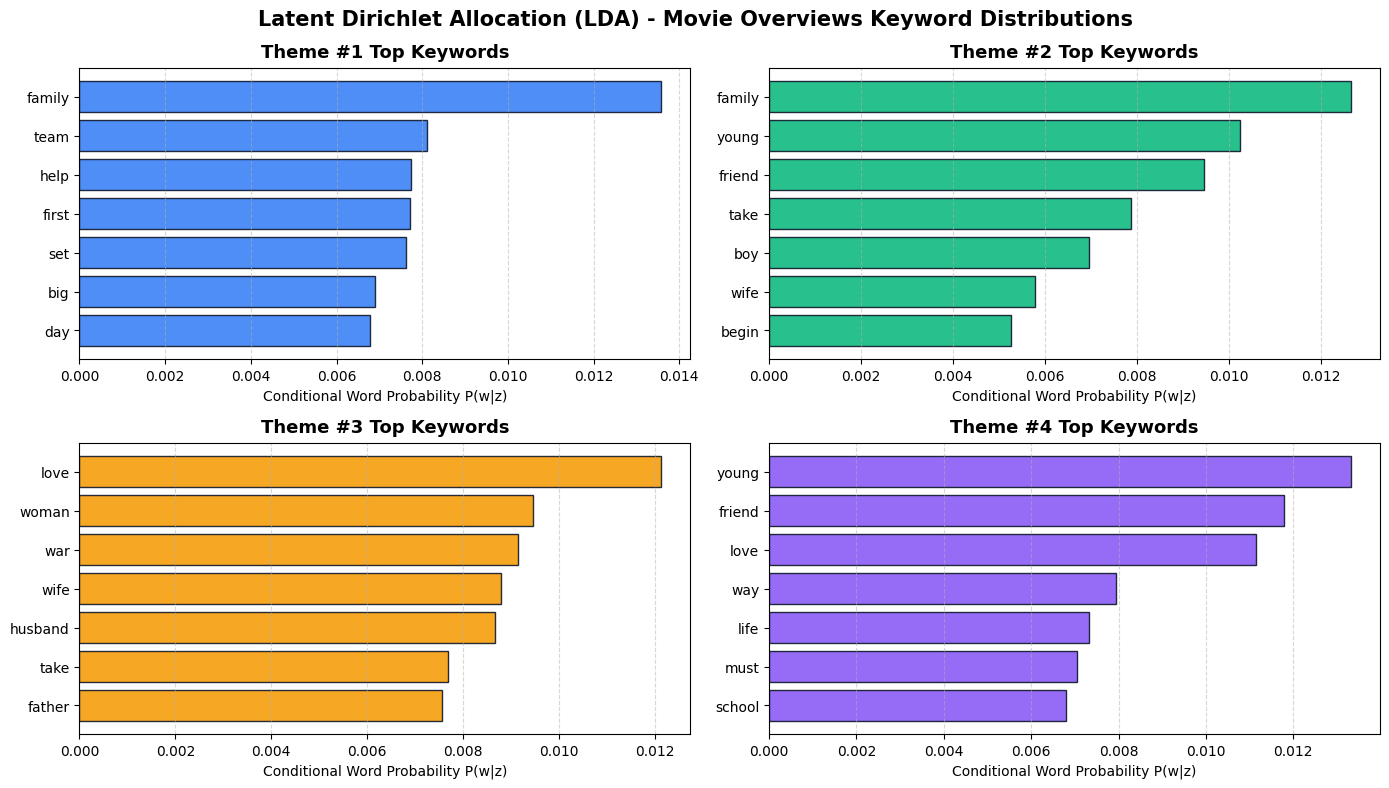

In [10]:
# Visualizing Top Terms per Topic
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharey=False)
axes = axes.flatten()

theme_colors = ['#3b82f6', '#10b981', '#f59e0b', '#8b5cf6']

for topic_id in range(4):
    top_terms = movie_lda.show_topic(topic_id, topn=7)
    words = [word for word, prob in top_terms][::-1]
    weights = [prob for word, prob in top_terms][::-1]
    
    ax = axes[topic_id]
    ax.barh(words, weights, color=theme_colors[topic_id], edgecolor='#0f172a', alpha=0.9)
    ax.set_title(f"Theme #{topic_id + 1} Top Keywords", fontsize=13, fontweight='bold', pad=8)
    ax.set_xlabel("Conditional Word Probability P(w|z)", fontsize=10)
    ax.grid(axis='x', linestyle='--', alpha=0.5)

plt.suptitle("Latent Dirichlet Allocation (LDA) - Movie Overviews Keyword Distributions", 
             fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()


---

<br><span style="  display: inline-block;  color: #fff;  background: linear-gradient(135deg, #a31616ff, #02b7ffff);  padding: 12px 20px;  border-radius: 12px;  font-size: 28px;  font-weight: 700;  box-shadow: 0 4px 12px rgba(0,0,0,0.2);  transition: transform 0.2s ease, box-shadow 0.2s ease;">  🧾 13. Review and Conclusion</span><br>

### Summary of What We Mastered:
1. **Unsupervised Topic Discovery**: Extracted latent thematic structures from unlabelled text corpora without human supervision.
2. **Preprocessing & Collocations**: Applied lemmatization, custom stopword removal, and Gensim `Phrases` for multi-word token discovery (`machine_learning`, `artificial_intelligence`).
3. **Gensim Dictionary & Filtering**: Converted raw tokens into compact integer maps and applied `filter_extremes` to suppress noise.
4. **LDA Theory & Priors**: Explored the generative process, Dirichlet distribution priors ($\alpha$ and $\eta$), and multinomial word selection.
5. **Model Evaluation**: Contrasted information-theoretic **Perplexity** with human-aligned **Topic Coherence ($C_v$)**.
6. **NMF vs. LDA**: Mastered linear algebraic factorization via Scikit-Learn's `NMF` alongside probabilistic LDA.
7. **End-to-End Project**: Extracted intuitive genre themes directly from real movie plots in `_datasets/movie_overviews.csv`.
